# Lecture 8a — Regularisation on data where you know the truth

**AI-powered Investment and Risk Management (25882) · Vitali Alexeev · UTS Business School**

Every empirical paper you read reports how well a model fitted *some* data. None of
them can tell you whether the model recovered the truth, because nobody knows what
the truth is.

This notebook removes that limitation. We simulate data where **we choose the truth**,
so we can measure not just how well each estimator predicts, but whether it found
what is actually there. Then we take the lessons to two real datasets.

### The argument, in four moves

1. Ordinary least squares fails badly when predictors are numerous — worse than
   predicting the mean.
2. Penalised regression fixes that, but the penalty that predicts best is **not**
   the penalty that identifies the true predictors.
3. Change one assumption about the world — whether the truth is concentrated or
   spread — and the ranking of lasso and ridge **inverts**. Nothing in the data
   tells you which world you are in.
4. Add nonlinearity and trees win; remove it and they lose. Choosing an estimator
   is a bet on the data-generating process.

### How to read this notebook

Prose carries the argument. Anything folded into a **collapsible box** is the
underlying mathematics — expand it if you want the derivation, skip it if you want
the intuition. Exercises at the foot are tiered **Core** and **Stretch**.

*Runtime: roughly 6–10 minutes end to end. British spelling throughout, except
where a library API forces otherwise (`l1_ratio`, `normalize`).*

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import airm8
from airm8 import *          # designs, estimators, metrics, figures

pd.set_option("display.precision", 3)
RNG = lambda seed: np.random.default_rng(seed)

print(f"airm8 loaded. Cache directory: {airm8.CACHE_DIR}")

airm8 loaded. Cache directory: C:\Users\Vitali\.airm8_cache


`airm8.py` holds the data-generating processes, the estimator suite and the figure
helpers. It is the same module that produced the figures in the lecture slides, so
what you see here and what you saw on the screen are generated by identical code.

---
## 1. Why not just use OLS?

Our first world has 100 predictors. **Ten of them genuinely drive the outcome; ninety
are pure noise.** The predictors come in ten correlated blocks, because in real data
characteristics cluster — book-to-market and earnings yield are not independent draws.

We have 200 observations. That ratio, $p/n = 0.5$, is not extreme by the standards of
the factor zoo, where $p$ runs into the hundreds and the effective $n$ is a few
hundred months.

In [2]:
sample = design_sparse(RNG(1))
print(sample)
print(f"\nTruly non-zero coefficients: {int(sample.support.sum())} of {len(sample.support)}")
print(f"Population R-squared: 0.40 — there is a great deal of real signal here.")

<Sample A: sparse linear: train (200, 100), test (5000, 100), 10 true>

Truly non-zero coefficients: 10 of 100
Population R-squared: 0.40 — there is a great deal of real signal here.


Now fit ordinary least squares and ask a simple question: does it beat forecasting
the historical mean?

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# NOTE: the scaler is fitted on TRAINING data only, then applied to test.
# Fitting it on the full sample would leak test information into training.
scaler = StandardScaler().fit(sample.X_train)
X_tr, X_te = scaler.transform(sample.X_train), scaler.transform(sample.X_test)

ols = LinearRegression().fit(X_tr, sample.y_train)

benchmark = sample.y_train.mean()          # the constant we must beat
r2_ols = oos_r2(sample.y_test, ols.predict(X_te), benchmark)

print(f"In-sample  R²: {ols.score(X_tr, sample.y_train): .3f}")
print(f"Out-of-sample R²: {r2_ols: .3f}")

In-sample  R²:  0.707
Out-of-sample R²: -0.388


The in-sample fit looks excellent. The out-of-sample $R^2$ is **negative**, which
means the model is actively harmful: you would have done better forecasting the
historical average and going home.

This is the whole problem in one number. OLS has enough freedom to explain the
training sample almost perfectly, and it spends that freedom on noise.

In [4]:
# Where did the coefficients go? Compare the true betas with what OLS estimated.
comparison = pd.DataFrame({
    "true": sample.beta,
    "OLS": ols.coef_,
}).assign(is_true=sample.support)

print("Mean |coefficient| on the 10 genuine predictors:")
print(f"   true {comparison.loc[comparison.is_true, 'true'].abs().mean():.3f}"
      f"   |   OLS {comparison.loc[comparison.is_true, 'OLS'].abs().mean():.3f}")
print("\nMean |coefficient| on the 90 noise predictors:")
print(f"   true 0.000   |   OLS {comparison.loc[~comparison.is_true, 'OLS'].abs().mean():.3f}")

Mean |coefficient| on the 10 genuine predictors:
   true 0.258   |   OLS 0.255

Mean |coefficient| on the 90 noise predictors:
   true 0.000   |   OLS 0.126


OLS assigns substantial weight to variables that have **no relationship whatsoever**
with the outcome. It cannot tell the difference, because in a finite sample the noise
predictors do correlate with the outcome by chance, and OLS has no reason to
disbelieve them.

<details>
<summary><b>The maths: why OLS variance explodes as $p$ approaches $n$</b> (click to expand)</summary>

The OLS estimator is $\hat\beta = (X'X)^{-1}X'y$ with variance
$\sigma^2 (X'X)^{-1}$. Writing the singular value decomposition
$X = UDV'$, the variance becomes $\sigma^2 V D^{-2} V'$, so the total
estimation variance is

$$\text{tr}\left[\mathrm{Var}(\hat\beta)\right] = \sigma^2 \sum_{j=1}^{p} \frac{1}{d_j^2}.$$

As $p \to n$ the smallest singular values $d_j$ approach zero, and this sum diverges.
The estimator remains *unbiased* the whole way down — it is simply unusable.

Correlated predictors make it worse: correlation shrinks the small singular values
directly, which is why the block structure in our design matters.

</details>

---
## 2. The three penalties

Penalised regression adds a cost for coefficient size. All three variants minimise
squared error *plus* a penalty:

$$\underbrace{\left(y - \beta_0 - \sum_i \beta_i x_i\right)^2}_{\text{fit}}
\; + \;
\lambda \left( \rho \sum_i |\beta_i| + \tfrac{1-\rho}{2} \sum_i \beta_i^2 \right)$$

- $\rho = 1$ → **lasso**, the $L_1$ penalty. Sets coefficients exactly to zero.
- $\rho = 0$ → **ridge**, the $L_2$ penalty. Shrinks everything, zeroes nothing.
- $0 < \rho < 1$ → **elastic net**.

> ⚠️ **Notation trap.** $\lambda$ is the *strength*; $\rho$ is the *mix*. In
> `scikit-learn` these are called `alpha` and `l1_ratio` respectively. `sklearn`'s
> `alpha` is **not** the $\alpha$ that appears as the mixing weight in most textbook
> treatments. Most broken student code traces back to this.

<details>
<summary><b>The maths: why $L_1$ produces exact zeros and $L_2$ does not</b> (click to expand)</summary>

Consider a single standardised, orthogonal predictor with OLS solution
$\hat\beta^{\text{OLS}}$. The penalised solutions have closed forms:

$$\hat\beta^{\text{ridge}} = \frac{\hat\beta^{\text{OLS}}}{1 + \lambda},
\qquad
\hat\beta^{\text{lasso}} = \text{sign}(\hat\beta^{\text{OLS}})
\left( |\hat\beta^{\text{OLS}}| - \lambda \right)_+ .$$

Ridge **multiplies** by a factor less than one, so it can never reach zero for
finite $\lambda$. The lasso **subtracts** a constant and truncates at zero, so any
coefficient smaller than $\lambda$ is eliminated outright. This is soft
thresholding.

Geometrically: the $L_1$ constraint region is a diamond with corners on the axes,
and the elliptical error contours tend to touch it *at* a corner. The $L_2$ region
is a sphere with no corners. **The sparsity of the lasso is a property of the shape
of the penalty, not a discovery about the world.**

</details>

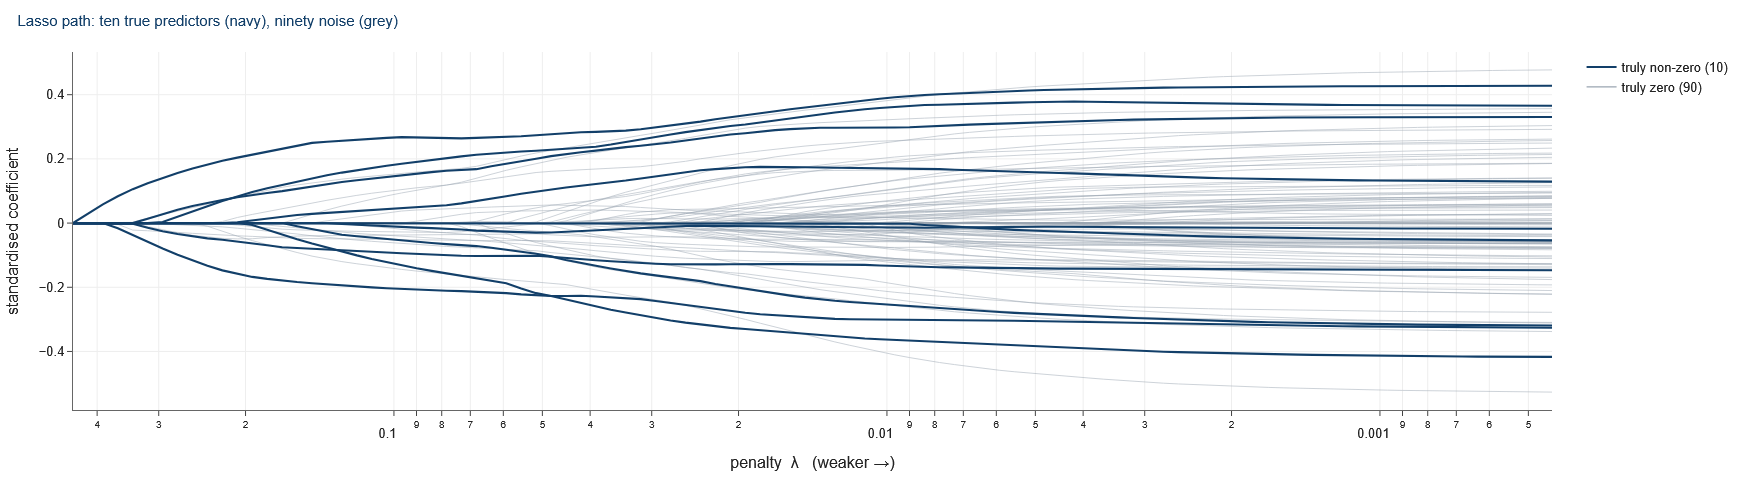

In [5]:
lambdas, coefs = lasso_path_data(sample, n_lambda=100)
plot_coef_path(lambdas, coefs, sample.support,
               title="Lasso path: ten true predictors (navy), ninety noise (grey)")

Read the figure **right to left**, from a weak penalty to a strong one. As $\lambda$
tightens, coefficients are driven to zero one by one.

Look carefully at the order in which they leave. Several grey lines — pure noise —
survive longer than several navy ones. Let us count that precisely.

In [6]:
# How many of the first k variables to enter the path are genuinely non-zero?
def n_true_among_first(s, k=10):
    lam_, co_ = lasso_path_data(s, n_lambda=100)
    entry = {}
    for j in range(co_.shape[1]):
        for i in np.where(np.abs(co_[:, j]) > 1e-8)[0]:
            entry.setdefault(i, j)
    return sum(s.support[i] for i in sorted(entry, key=entry.get)[:k])

# One sample is not enough: this statistic is noisy, so average over seeds.
counts = np.array([n_true_among_first(design_sparse(RNG(seed)))
                   for seed in range(20)])

print(f"Of the first 10 variables to enter the lasso path, the number that")
print(f"are genuinely non-zero, across 20 samples:")
print(f"   mean {counts.mean():.1f}    range {counts.min()} to {counts.max()}")
print(f"\nSo roughly {10 - counts.mean():.0f} of the first 10 variables to enter")
print(f"are noise that happened to correlate with y in that sample.")

Of the first 10 variables to enter the lasso path, the number that
are genuinely non-zero, across 20 samples:
   mean 6.0    range 4 to 8

So roughly 4 of the first 10 variables to enter
are noise that happened to correlate with y in that sample.


### Watch the penalty work

Drag the slider from left to right to tighten $\lambda$. Navy bars are the true
predictors, grey bars are noise. Notice how much noise survives at the penalties
where the true coefficients are still meaningfully large.

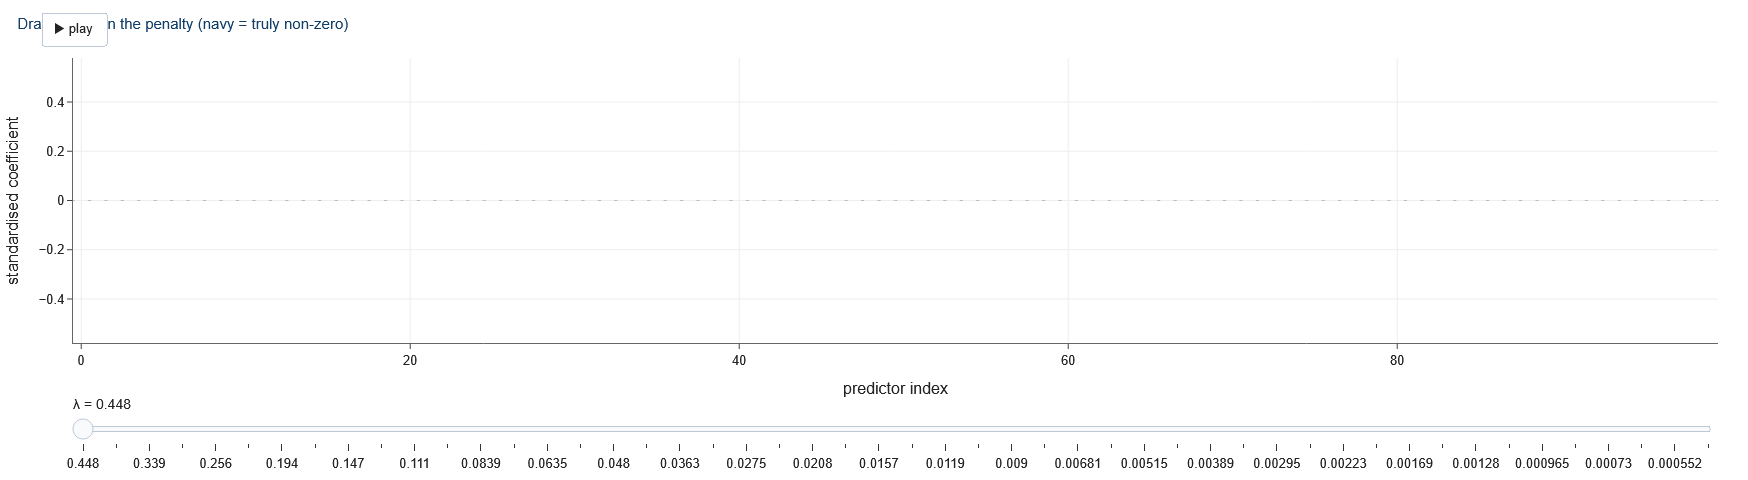

In [7]:
plot_coef_path_animated(lambdas[::2], coefs[:, ::2], sample.support,
                        title="Drag to tighten the penalty (navy = truly non-zero)")

---
## 3. What does the lasso actually select?

The claim that "regularisation performs feature selection" is repeated everywhere.
Let us test it, using the fact that we know the answer.

For each penalty we record three things:

- **out-of-sample $R^2$** — how well it predicts;
- **precision** — of the variables it selected, what share are genuinely non-zero;
- **recall** — of the genuinely non-zero variables, what share did it find.

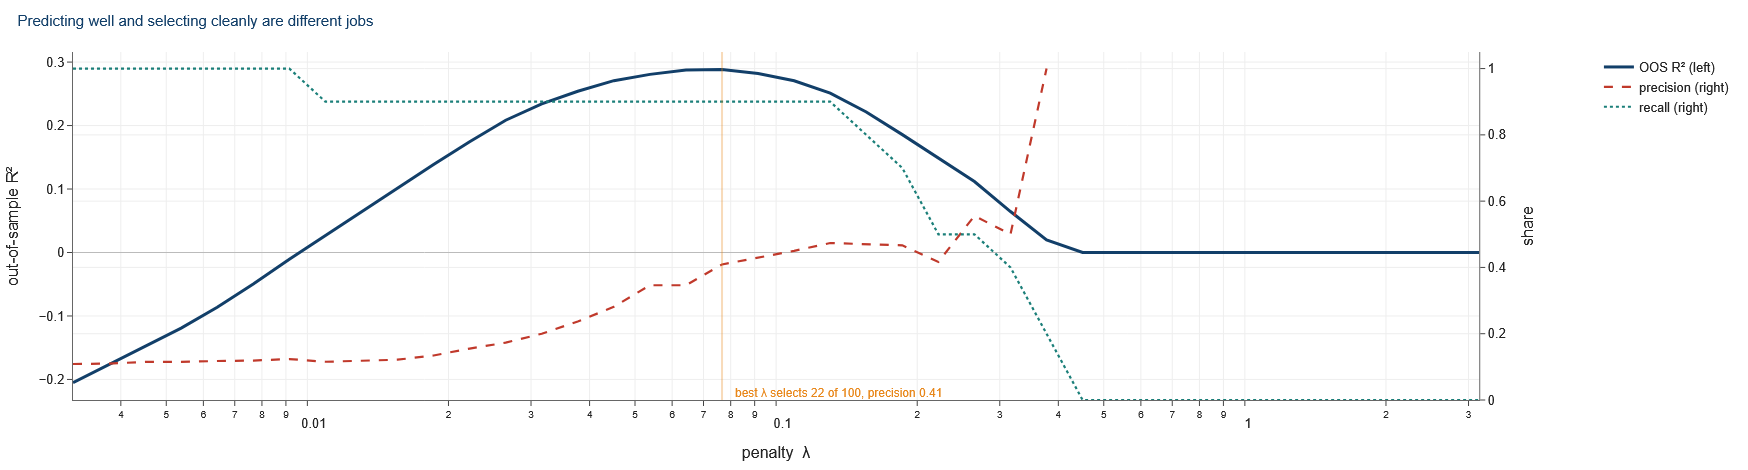

In [8]:
sweep = sweep_penalty(sample, model="lasso")
plot_precision_recall(sweep, n_features=100,
                      title="Predicting well and selecting cleanly are different jobs")

In [9]:
best = sweep.loc[sweep.oos_r2.idxmax()]
print(f"At the λ that maximises out-of-sample R² (λ = {best.lam:.4f}):")
print(f"   out-of-sample R²  {best.oos_r2:.3f}")
print(f"   variables kept    {best.n_selected:.0f} of 100")
print(f"   precision         {best.precision:.3f}   "
      f"→ about {best.n_selected * (1 - best.precision):.0f} of them are noise")
print(f"   recall            {best.recall:.3f}")

clean = sweep[sweep.precision > 0.55]
if len(clean):
    row = clean.loc[clean.oos_r2.idxmax()]
    print(f"\nIf instead we insist on precision above 0.55:")
    print(f"   out-of-sample R² falls to {row.oos_r2:.3f} "
          f"(from {sweep.oos_r2.max():.3f})")
    print(f"   and recall collapses to {row.recall:.3f}")

At the λ that maximises out-of-sample R² (λ = 0.0767):
   out-of-sample R²  0.288
   variables kept    22 of 100
   precision         0.409   → about 13 of them are noise
   recall            0.900

If instead we insist on precision above 0.55:
   out-of-sample R² falls to 0.112 (from 0.288)
   and recall collapses to 0.500


**This is the finding worth carrying out of the notebook.** The penalty that
forecasts best keeps roughly a third of the variables, and most of what it keeps is
noise. Tighten the penalty until the selected set is clean, and predictive
performance collapses.

Prediction and selection are **different objectives that want different penalties**,
and you cannot serve both at once.

Two practical consequences:

- If you are forecasting, do not read the selected support as a list of things that
  matter. It is not one.
- If you want to know which factors are priced, the lasso alone is not a valid tool.
  Selection mistakes bias the coefficients that survive. Feng, Giglio and Xiu (2020)
  build the double-selection correction that fixes this.

---
## 4. Now change one thing about the world

Everything so far assumed the truth is **sparse**: ten predictors matter, ninety are
irrelevant. That is an assumption, and it is exactly the assumption the lasso encodes.

Suppose instead the truth is **dense**: all hundred predictors matter, each a little.
Same sample size, same population $R^2$, same code. Only the world changes.

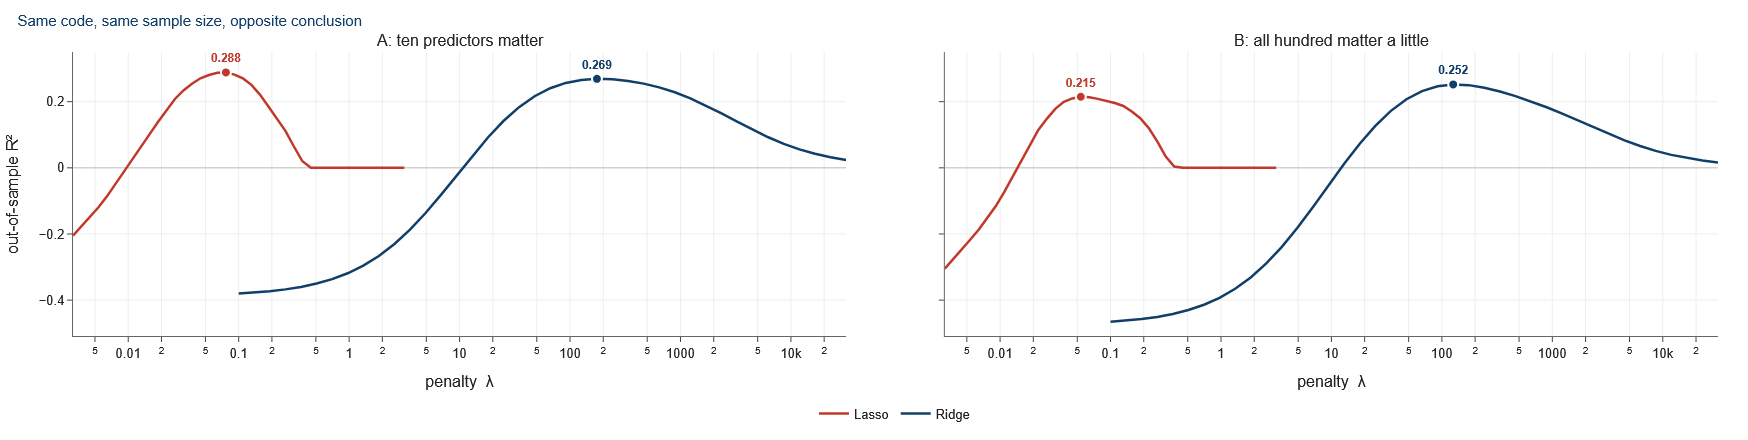

In [10]:
sample_dense = design_dense(RNG(2))

sweeps = {}
for name, s in [("A: ten predictors matter", sample),
                ("B: all hundred matter a little", sample_dense)]:
    sweeps[name] = pd.concat([sweep_penalty(s, "lasso"),
                              sweep_penalty(s, "ridge")], ignore_index=True)

plot_lambda_sweep(sweeps, title="Same code, same sample size, opposite conclusion")

In [11]:
rows = []
for name, df in sweeps.items():
    for model in ["lasso", "ridge"]:
        s = df[df.model == model]
        b = s.loc[s.oos_r2.idxmax()]
        rows.append(dict(world=name, model=model,
                         best_oos_r2=b.oos_r2, best_lambda=b.lam))
summary = pd.DataFrame(rows).pivot(index="world", columns="model",
                                   values="best_oos_r2")
print(summary.round(3).to_string())
print("\nWinner by world:")
for w in summary.index:
    print(f"   {w:34s} → {summary.loc[w].idxmax()}")

model                           lasso  ridge
world                                       
A: ten predictors matter        0.288  0.269
B: all hundred matter a little  0.215  0.252

Winner by world:
   A: ten predictors matter           → lasso
   B: all hundred matter a little     → ridge


**The ranking inverts.** Ridge barely notices the change; the lasso loses badly.

The reason is that ridge's assumption — many things matter a little — happens to be
true in the second world, and *approximately* true in the first, since shrinking ten
large coefficients slightly is not very costly. The lasso's assumption is either
right or badly wrong, with no middle ground.

### The economics

This is not a technical curiosity. It is the central argument of Kozak, Nagel and
Santosh (2020), *Shrinking the Cross-Section*:

> If a few characteristics really did summarise the cross-section of expected returns,
> the dozens of documented anomalies would have to be almost perfectly redundant. No
> asset pricing theory implies that.

Their conclusion: a **characteristics-sparse** stochastic discount factor cannot
summarise the cross-section. Shrinkage, not selection, is the appropriate response to
the factor zoo — and shrinkage applied in the space of *principal components* rather
than raw characteristics.

Choosing between ridge and lasso is therefore an **economic** decision about the
structure of the cross-section, not a computational preference.

---
## 5. When predictors travel in packs

Real characteristics are correlated. Book-to-market, earnings yield and cash-flow
yield all measure something close to "cheapness".

Here are five predictors with pairwise correlation 0.95, **all five genuinely
non-zero**. What does each estimator do with the cluster?

In [12]:
from sklearn.linear_model import LassoCV, ElasticNetCV

results = []
for rep in range(20):
    s = design_correlated_group(RNG(500 + rep))
    for name in ["Lasso", "Elastic net"]:
        est = linear_only(seed=rep)[name].fit(s.X_train, s.y_train)
        c = coefficients(est)
        cluster = np.abs(c[:5])
        results.append(dict(
            estimator=name,
            kept=int((cluster > 1e-8).sum()),
            concentration=cluster.max() / max(cluster.sum(), 1e-12),
            oos_r2=oos_r2(s.y_test, est.predict(s.X_test), s.y_train.mean())))

print(pd.DataFrame(results).groupby("estimator").mean(numeric_only=True).round(3).to_string())
print("\n'kept'          = how many of the 5 cluster members get a non-zero coefficient")
print("'concentration' = largest cluster coefficient / sum; 1.0 means winner-takes-all")

             kept  concentration  oos_r2
estimator                               
Elastic net  3.75          0.476   0.372
Lasso        3.10          0.599   0.373

'kept'          = how many of the 5 cluster members get a non-zero coefficient
'concentration' = largest cluster coefficient / sum; 1.0 means winner-takes-all


The textbook claim is that the lasso "chooses one variable from such groups and
ignores the rest entirely". Measured, that is an **overstatement** — it keeps closer
to three of the five, and the elastic net keeps slightly more.

More importantly, look at the out-of-sample $R^2$ column: the two are essentially
identical. The elastic net's grouping property is real, but here it buys **no
predictive accuracy at all**. It buys stability of the selected set, which matters if
you intend to interpret that set — and Part 3 has already warned you against doing
that.

---
## 6. When linearity fails

Everything so far assumed the truth is linear. Our third world is not: the outcome
depends on **thresholds** and a **product** of two predictors.

$$f(x) = 1.5\,\mathbb{1}[x_1 > 0.5] + 1.5\,\text{sign}(x_2)\mathbb{1}[|x_2| > 1] + 2 x_3 x_4 - \mathbb{1}[x_5 < -0.5]\mathbb{1}[x_6 > 0]$$

No linear model can represent this, however you penalise it. Tree ensembles can:
a tree partitions the predictor space into rectangles, so thresholds and interactions
come free.

In [13]:
designs = {
    "A: sparse linear": design_sparse,
    "B: dense linear": design_dense,
    "C: nonlinear": design_nonlinear,
}

rows = []
for design_name, maker in designs.items():
    for rep in range(10):                        # raise to 50 to match the slides
        s = maker(RNG(1000 + rep))
        bench = s.y_train.mean()
        for est_name, est in estimator_suite(seed=rep).items():
            est.fit(s.X_train, s.y_train)
            rows.append(dict(design=design_name, estimator=est_name, rep=rep,
                             oos_r2=oos_r2(s.y_test, est.predict(s.X_test), bench)))

grid = pd.DataFrame(rows)
order = ["OLS", "Ridge", "Lasso", "Elastic net", "Random forest", "Grad. boosting"]
table = grid.pivot_table("oos_r2", "estimator", "design", "mean").reindex(order)
print(table.round(3).to_string())

design          A: sparse linear  B: dense linear  C: nonlinear
estimator                                                      
OLS                       -0.225           -0.230        -0.905
Ridge                      0.263            0.262         0.017
Lasso                      0.286            0.220         0.019
Elastic net                0.285            0.247         0.020
Random forest              0.167            0.175         0.140
Grad. boosting             0.134            0.141         0.108


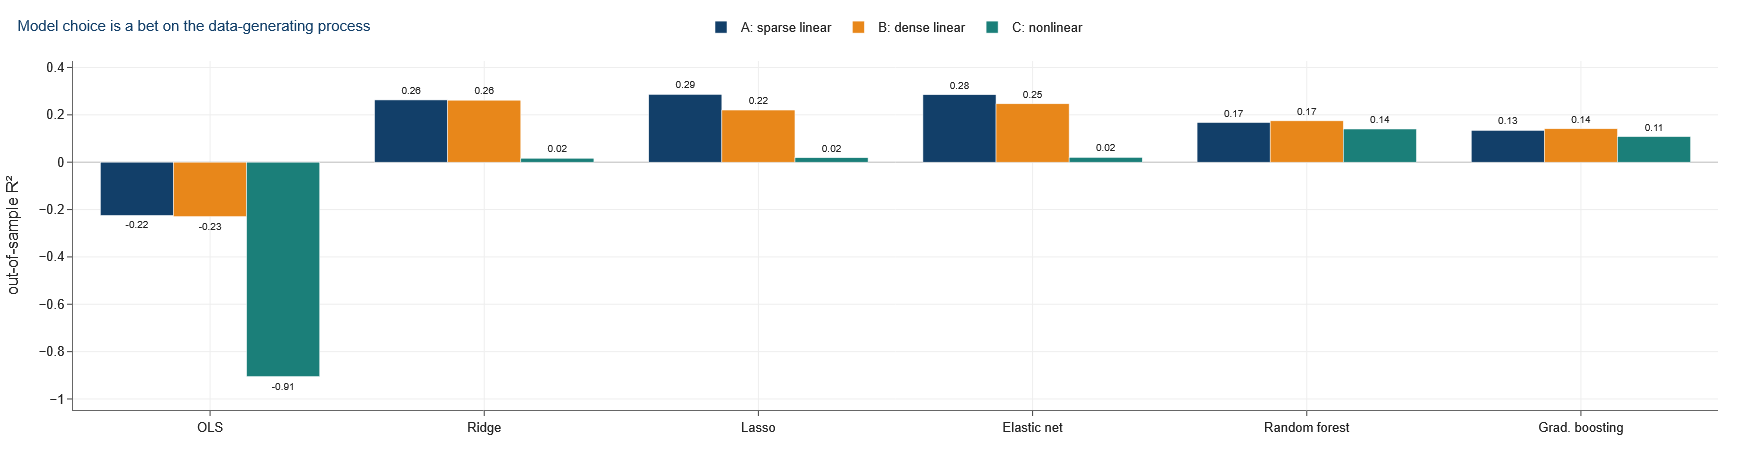

In [14]:
plot_estimator_comparison(table,
                          title="Model choice is a bet on the data-generating process")

Read the table by row, not by column.

- **The lasso wins under sparsity and loses under density.** Its assumption is doing
  the work.
- **Random forests win the nonlinear world and lose both linear worlds**, giving up
  roughly 40% of the achievable $R^2$ on Design A. Flexibility you do not need is not
  free — you pay for it in variance.
- **Gradient boosting loses to the forest even where trees should win.** At $n = 200$,
  early stopping consumes a fifth of an already small training set. Boosting is a
  large-sample method, and this is not a large sample.
- **OLS is negative everywhere.**

There is no estimator that is safe to reach for by default, and — this is the part
that matters — **no diagnostic in the data reliably tells you which world you are
in**. You are always making a bet.

---
## 7. Real data, part one: California house prices

Simulations are clean because we built them. Real data is not. This dataset records
median house values across California census districts in 1990, with eight
predictors including location.

It is not finance, and that is deliberate: it is a case where we have strong prior
reason to expect **genuine nonlinearity**. House prices depend on latitude and
longitude jointly — that is what "location" means — and no additive model in
latitude and longitude can express it.

If the download is blocked on your network the notebook falls back to a bundled
dataset with quite different structure. Read the interpretation cell below rather
than assuming which way the result went.

In [3]:
try:
    X_cal, y_cal = load_california()
    DATASET = "California housing"
except FileNotFoundError as err:
    print(f"{err}\n\nFalling back to the bundled diabetes dataset.")
    X_cal, y_cal = load_diabetes_frame()
    DATASET = "Diabetes (fallback)"

print(f"\n{DATASET}: {X_cal.shape[0]:,} rows, {X_cal.shape[1]} predictors")
X_cal.head()


California housing: 20,640 rows, 8 predictors


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.325,41.0,6.984,1.024,322.0,2.556,37.88,-122.23
1,8.301,21.0,6.238,0.972,2401.0,2.110,37.86,-122.22
2,7.257,52.0,8.288,1.073,496.0,2.802,37.85,-122.24
3,5.643,52.0,5.817,1.073,558.0,2.548,37.85,-122.25
4,3.846,52.0,6.282,1.081,565.0,2.181,37.85,-122.25


In [4]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(X_cal.values, y_cal.values,
                                      test_size=0.3, random_state=0)
bench = ytr.mean()

real = {}
for name, est in estimator_suite(seed=0).items():
    est.fit(Xtr, ytr)
    real[name] = oos_r2(yte, est.predict(Xte), bench)

print(pd.Series(real).round(3).sort_values(ascending=False).to_string())

Grad. boosting    0.822
Random forest     0.800
Elastic net       0.593
OLS               0.593
Lasso             0.593
Ridge             0.592


In [5]:
gap = max(real["Random forest"], real["Grad. boosting"]) - \
      max(real["Ridge"], real["Lasso"], real["Elastic net"])

print(f"Best tree ensemble minus best penalised linear model: {gap:+.3f}\n")
if gap > 0.02:
    print("Trees win. This dataset contains interactions and thresholds that no")
    print("additive linear model can represent — Design C, in the wild.")
elif gap < -0.02:
    print("The LINEAR models win. Whatever structure this dataset has is close")
    print("enough to additive that the extra flexibility of trees costs more in")
    print("variance than it recovers in bias — Design A, in the wild.")
else:
    print("Essentially a tie: neither family has an edge worth acting on here.")

print(f"\nPenalised minus OLS: "
      f"{max(real['Ridge'], real['Lasso']) - real['OLS']:+.3f}")

Best tree ensemble minus best penalised linear model: +0.229

Trees win. This dataset contains interactions and thresholds that no
additive linear model can represent — Design C, in the wild.

Penalised minus OLS: -0.000


Whichever way that comparison came out, notice the **second** number: penalised
regression barely improves on OLS on this dataset. With thousands of observations
and a handful of predictors, $p/n$ is tiny and there is nothing for shrinkage to do.

**Regularisation solves a specific problem — too many parameters relative to
observations. It is not a general-purpose improvement,** and applying it where that
problem is absent buys nothing.

If you are running the diabetes fallback rather than California housing, the linear
models will have won. That is not a bug in the notebook; it is Part 6 repeating
itself on real data. The diabetes predictors are already standardised, roughly
additive, and few. Trees have no interactions to find, so their flexibility is pure
cost. **The lesson is the same either way: match the estimator to the structure, and
you cannot read the structure off the data.**

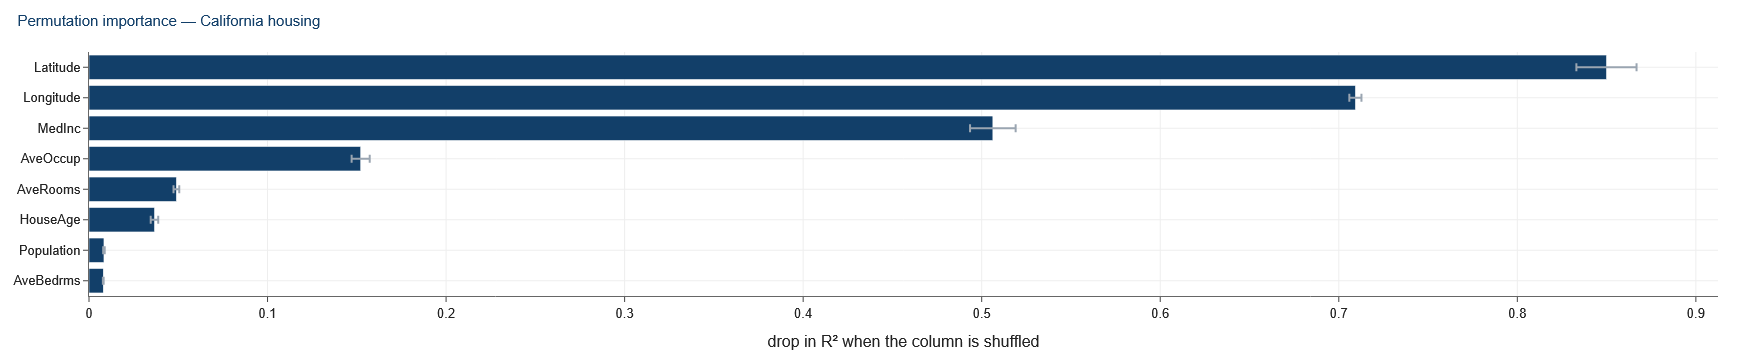

In [6]:
# Which predictors is the model using, and how?
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingRegressor

gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                    random_state=0).fit(Xtr, ytr)

pi = permutation_importance(gbm, Xte, yte, n_repeats=5, random_state=0)
plot_importance(list(X_cal.columns), pi.importances_mean, pi.importances_std,
                title=f"Permutation importance — {DATASET}")

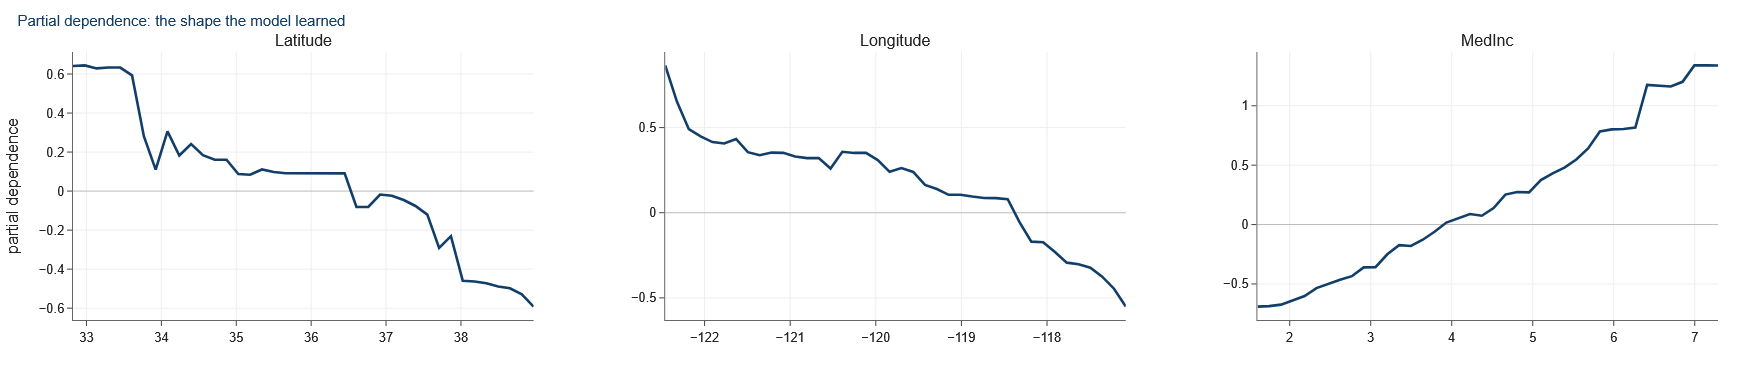

In [7]:
top3 = np.argsort(pi.importances_mean)[-3:][::-1]
plot_partial_dependence(gbm, Xtr, list(top3), list(X_cal.columns),
                        title="Partial dependence: the shape the model learned")

Partial dependence shows the marginal shape the model has learned for each predictor.
Where those shapes bend, kink or reverse, a linear coefficient would have been
averaging over something real.

Two warnings about these plots, since they are heavily over-interpreted in practice:

- Partial dependence is an **average over the other predictors**. If the effect of one
  variable depends on another — exactly the interaction we came here to find — the
  marginal plot hides it.
- Permutation importance measures **how much the model relies on a column**, not how
  much that column matters in the world. Shuffle one of two correlated predictors and
  the model leans on its twin, so both look unimportant.

---
## 8. Real data, part two: predicting the equity premium

Now a finance problem, and a genuinely hard one.

Welch and Goyal (2008) asked whether the standard predictors of the equity risk
premium — dividend yield, earnings yield, term spread, default spread and the rest —
actually forecast out of sample. Their answer was largely no. Goyal, Welch and
Zafirov (2024) revisited it with the predictors published since: more than a third
lose significance even in-sample, and half of the survivors fail out of sample.

This is the honest backdrop for everything in this subject. **Return prediction is
close to the hardest forecasting problem in applied statistics.**

In [8]:
HAVE_GW = False
try:
    gw = load_goyal_welch()
    HAVE_GW = True
    print(f"Loaded {len(gw):,} monthly observations, "
          f"{gw.index.min():%Y-%m} to {gw.index.max():%Y-%m}")
except (FileNotFoundError, ValueError) as err:
    print("Equity premium data unavailable — this section will be skipped.\n")
    print(err)
    print("\nEverything above runs without it. To enable this section, mirror the")
    print("Goyal-Welch file into the teaching repository and set AIRM8_GW_URL.")

Loaded 1,860 monthly observations, 1871-01 to 2025-12


In [9]:
if HAVE_GW:
    # Standard predictor set. Anything absent from this vintage is dropped.
    wanted = ["dp", "dy", "ep", "de", "svar", "bm", "ntis", "tbl",
              "lty", "ltr", "tms", "dfy", "dfr", "infl"]
    cols = [c for c in wanted if c in gw.columns]

    data = gw[cols + ["equity_premium"]].dropna()
    # Predict NEXT month from THIS month's predictors.
    y = data["equity_premium"].shift(-1).iloc[:-1]
    X = data[cols].iloc[:-1]

    print(f"{len(X):,} months, {len(cols)} predictors: {', '.join(cols)}")

1,188 months, 14 predictors: dp, dy, ep, de, svar, bm, ntis, tbl, lty, ltr, tms, dfy, dfr, infl


In [10]:
if HAVE_GW:
    from sklearn.linear_model import Ridge, LinearRegression

    # Expanding window. At each date we use ONLY data available at that date:
    # refit the model, refit the scaler, and refit the benchmark mean.
    START = 240                               # 20 years of burn-in
    preds = {"Historical mean": [], "Kitchen-sink OLS": [], "Ridge": []}
    actual, bench_path = [], []

    for t in range(START, len(X)):
        X_hist, y_hist = X.iloc[:t].values, y.iloc[:t].values
        x_now = X.iloc[[t]].values

        mu, sd = X_hist.mean(0), X_hist.std(0) + 1e-12
        Xs, xs = (X_hist - mu) / sd, (x_now - mu) / sd

        preds["Historical mean"].append(y_hist.mean())
        preds["Kitchen-sink OLS"].append(
            LinearRegression().fit(Xs, y_hist).predict(xs)[0])
        preds["Ridge"].append(
            Ridge(alpha=50.0).fit(Xs, y_hist).predict(xs)[0])

        actual.append(y.iloc[t])
        bench_path.append(y_hist.mean())

    actual = np.array(actual)
    bench_path = np.array(bench_path)

    print("Out-of-sample R² against the prevailing historical mean:\n")
    for name, p in preds.items():
        p = np.array(p)
        r2 = 1 - np.sum((actual - p) ** 2) / np.sum((actual - bench_path) ** 2)
        print(f"   {name:20s} {r2: .4f}")

Out-of-sample R² against the prevailing historical mean:

   Historical mean       0.0000
   Kitchen-sink OLS     -0.2168
   Ridge                -0.0851


The numbers are sobering and they are supposed to be. Over 948 months of genuine
out-of-sample forecasting — 1946 to 2025 — nothing beats the historical average.

- The **kitchen-sink** regression posts an out-of-sample $R^2$ of about
  $-0.22$. Fourteen predictors and a few hundred months is the Part 1 problem all
  over again, on real data.
- **Ridge** more than halves the damage, to roughly $-0.09$. Shrinkage helps a great
  deal and still does not get you to zero.

This is the Welch and Goyal (2008) result, and Goyal, Welch and Zafirov (2024)
confirmed it holds for the predictors published since. **Predicting the equity
premium is close to the hardest forecasting problem in applied statistics**, and
anyone claiming otherwise should be asked for their out-of-sample period.

An $R^2$ near or below zero does not automatically mean a forecast is worthless: a
badly scaled forecast can post a negative $R^2$ while still ordering outcomes
correctly, and it is the ordering that pays. But it does mean you have not beaten a
strategy requiring no data, no model and no effort.

In [11]:
if HAVE_GW:
    # Campbell & Thompson (2008): impose the economic restriction that the
    # expected equity premium cannot be negative. Truncate at zero.
    print("With the Campbell-Thompson sign restriction imposed:\n")
    for name, p in preds.items():
        p = np.maximum(np.array(p), 0.0)
        r2 = 1 - np.sum((actual - p) ** 2) / np.sum((actual - bench_path) ** 2)
        print(f"   {name:20s} {r2: .4f}")

With the Campbell-Thompson sign restriction imposed:

   Historical mean       0.0000
   Kitchen-sink OLS     -0.0362
   Ridge                -0.0148


In [12]:
if HAVE_GW:
    print("How much did each intervention buy?\n")
    for name in ["Kitchen-sink OLS", "Ridge"]:
        raw = np.array(preds[name])
        r2_raw = 1 - np.sum((actual - raw) ** 2) / np.sum((actual - bench_path) ** 2)
        cut = np.maximum(raw, 0.0)
        r2_cut = 1 - np.sum((actual - cut) ** 2) / np.sum((actual - bench_path) ** 2)
        print(f"   {name:18s} {r2_raw: .4f}  ->  {r2_cut: .4f}   "
              f"(gain {r2_cut - r2_raw:+.4f})")

    print("\nFor comparison, moving from OLS to ridge — a purely statistical")
    print("intervention — bought about +0.13. The sign restriction, which is one")
    print("line of economics, bought more than that on the kitchen sink alone.")

How much did each intervention buy?

   Kitchen-sink OLS   -0.2168  ->  -0.0362   (gain +0.1806)
   Ridge              -0.0851  ->  -0.0148   (gain +0.0703)

For comparison, moving from OLS to ridge — a purely statistical
intervention — bought about +0.13. The sign restriction, which is one
line of economics, bought more than that on the kitchen sink alone.


Truncating negative forecasts at zero is not a statistical trick — it is an **economic
restriction**. Investors do not hold risky assets expecting to lose money relative to
cash, so a model forecasting a negative premium is saying something implausible.

Look at what it bought. The sign restriction takes the kitchen sink from $-0.22$ to
about $-0.04$, recovering most of the damage in a single line of code that contains
no statistics at all. Ridge improves to roughly $-0.01$.

**This is the most important idea in the notebook.** Economic structure is
information, and imposing it is a form of regularisation — often a more powerful one
than anything in the statistics toolkit. The same idea runs through the rest of the
lecture: Kozak, Nagel and Santosh's prior ruling out near-arbitrage is, mathematically,
a ridge penalty applied in the coordinate system the economics picks out.

Neither model beats the historical mean even now. But the gap closed far more from
knowing something about markets than from knowing something about estimators.

---
## Exercises

### Core

**C1.** Re-run Part 1 with `n_train = 500` and then `n_train = 1000`, holding
$p = 100$ fixed. At what ratio $p/n$ does OLS start to beat the historical mean?
Does the crossing point move when you change the population $R^2$?

**C2.** In Part 3, we found the penalty that maximises out-of-sample $R^2$ selects
about a third of the variables at low precision. Find the penalty that maximises the
**F1 score** of the selected support instead. How much predictive performance does
that cost?

**C3.** Design B gave ridge the advantage. Construct an intermediate world — say 30
predictors matter and 70 do not — and locate roughly where the crossover between
lasso and ridge happens. What does that tell you about how much sparsity the lasso
needs before it earns its place?

**C4.** Refit Part 7 using only `Latitude` and `Longitude` as predictors, once with
ridge and once with a gradient-boosting model. Explain the gap in one paragraph
without using the word "nonlinear".

### Stretch

**S1.** Our nonlinear design uses thresholds and one product term. Write a design
whose signal is *smooth* but nonlinear — a sine, say — and rerun the Part 6
comparison. Do trees still win? Should they?

**S2.** In Part 5, the elastic net keeps more of the correlated cluster but does not
predict better. Construct a case where the grouping property **does** improve
out-of-sample $R^2$. What did you have to assume to make that happen?

**S3.** Every result in this notebook uses a single train/test split or a fixed
number of replications. Rerun Part 6 with 50 replications and report standard errors
alongside the means. Which of the rankings in the table survive, and which turn out
to be within noise?

**S4.** The Part 8 expanding window refits the scaler at every date, which is correct
but slow. Deliberately break it: fit the scaler once on the full sample, rerun, and
report how much the out-of-sample $R^2$ improves. That improvement is the size of the
leak — and it is exactly the bug that was present in the 2024 version of this lab.

**S5.** Ridge in Part 8 uses a fixed `alpha=50`. Choose it properly instead, by
cross-validating **within** each expanding window using only data available at that
date. Does honest tuning help, or does the extra estimation noise cost more than it
gains?

---

### Where this goes next

**Lecture 8b** takes these tools to the real factor zoo: roughly 200 replicated
anomaly portfolios, free to download. You will plot the distribution of
$t$-statistics across every published signal, watch what a multiple-testing hurdle
does to the survivor count, and build a shrinkage-based stochastic discount factor
in the manner of Kozak, Nagel and Santosh.